# Video Segmentation Technique for Tracking Movement

My idea:
- use image segmentation technique to only get blue gloves from a frame
- track speed of movement and so on from the segmented frame

Glove color based segmentation:
1. Source: https://medium.com/@karen.mossoyan/hand-segmentation-with-python-and-tensorflow-70c38db855b5
- teaches the basic of selecting the right model to train the segmentation 
- but to train the model I need to have ground truth mask
- NOTE: Interesting thing to learn if I have time 📕
2. Source: https://realpython.com/python-opencv-color-spaces/
- focus on image segmentation from color space instead of using deep learning model 
- this is what I will be following hehe

In [ ]:
# first lets extract frames out from a video
# video dir -- /tmp/Y54I_trimmed_1min.mp4

# Modified from Source - https://stackoverflow.com/a/33399711
# Posted by fireant, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-07, License - CC BY-SA 4.0

import cv2
vidcap = cv2.VideoCapture('/tmp/Y54I_trimmed_1min.mp4')
success,image = vidcap.read()
count = 0
while success:
  cv2.imwrite("frame_result/frame%d.jpg" % count, image)     # save frame as JPEG file
  success,image = vidcap.read()
  count += 1
print(f"done: got {count} frames")
# got 1800 frames out of 60 second videos

done: got 1800 frames


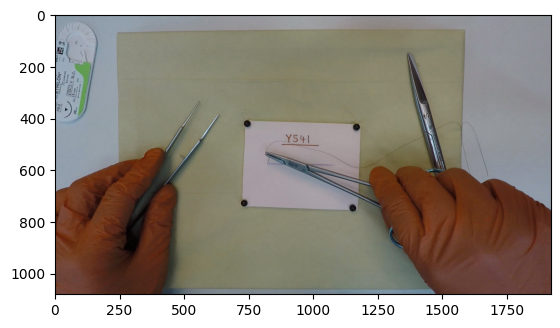

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# first lets read a frame to see how it looks like
frame0 = cv2.imread("./frame_result/frame0.jpg")
plt.imshow(frame0)
plt.show()

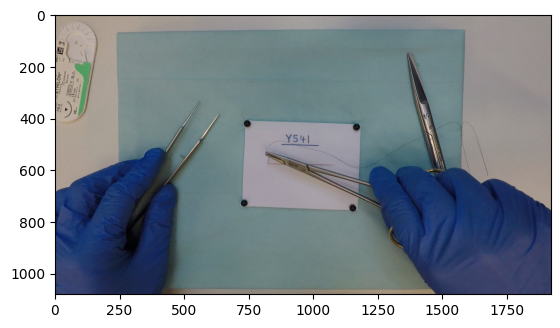

In [8]:
# cv2 read image in BGR format -- change to RGB with the folling
frame0 = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
plt.imshow(frame0)
plt.show()

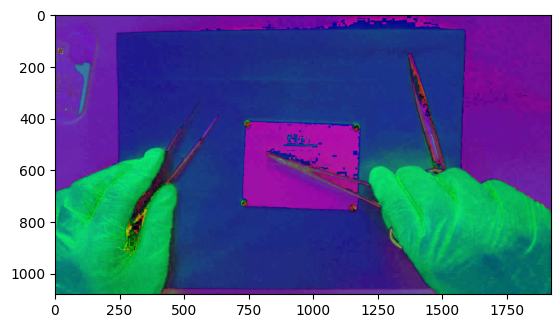

In [14]:
frame0 = cv2.cvtColor(frame0, cv2.COLOR_RGB2HSV)
plt.imshow(frame0)
plt.show()

In [10]:
# lets observe RGB color space with frame0 : https://realpython.com/python-opencv-color-spaces/
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib import colors

def plot_color_space(frame: list[list[int]]) -> None:
    r, g, b = cv2.split(frame) # split image into its component channels
    fig = plt.figure()
    axis = fig.add_subplot(1, 1, 1, projection="3d")

    pixel_colors = frame.reshape((np.shape(frame)[0]*np.shape(frame)[1], 3))
    norm = colors.Normalize(vmin=-1.,vmax=1.)
    norm.autoscale(pixel_colors)
    pixel_colors = norm(pixel_colors).tolist()

    axis.scatter(r.flatten(), g.flatten(), b.flatten(), facecolors=pixel_colors, marker=".")
    axis.set_xlabel("Red")
    axis.set_ylabel("Green")
    axis.set_zlabel("Blue")
    plt.show()

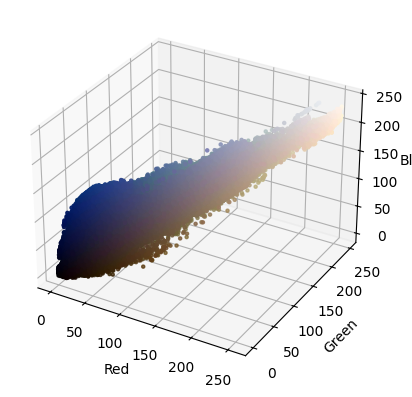

In [11]:
plot_color_space(frame0)

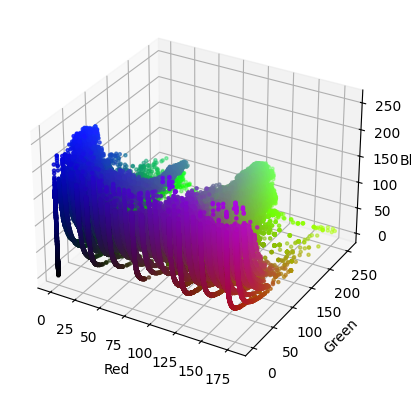

In [ ]:
# the green means the blue gloves -- now we can see that it is more seggreagted
hsv_frame0 = cv2.cvtColor(frame0, cv2.COLOR_RGB2HSV)
plot_color_space(hsv_frame0)